Loading market data...
--- Simulation Start ---
Initial Price: $3830.83
LP Position: 1.3052 ETH + 5000.00 USDC


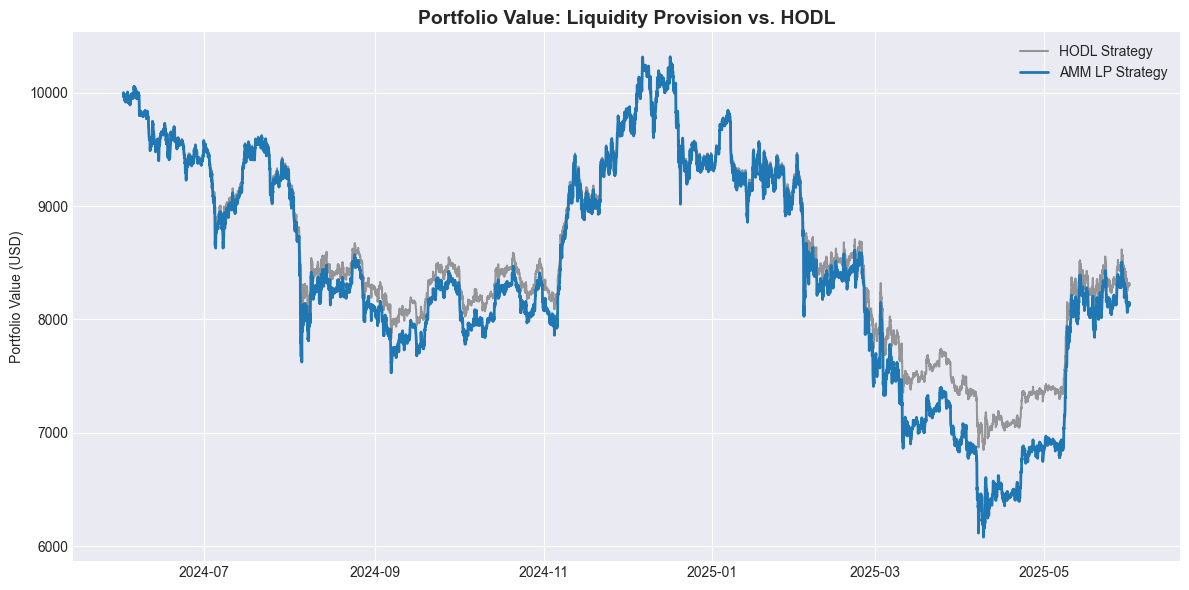

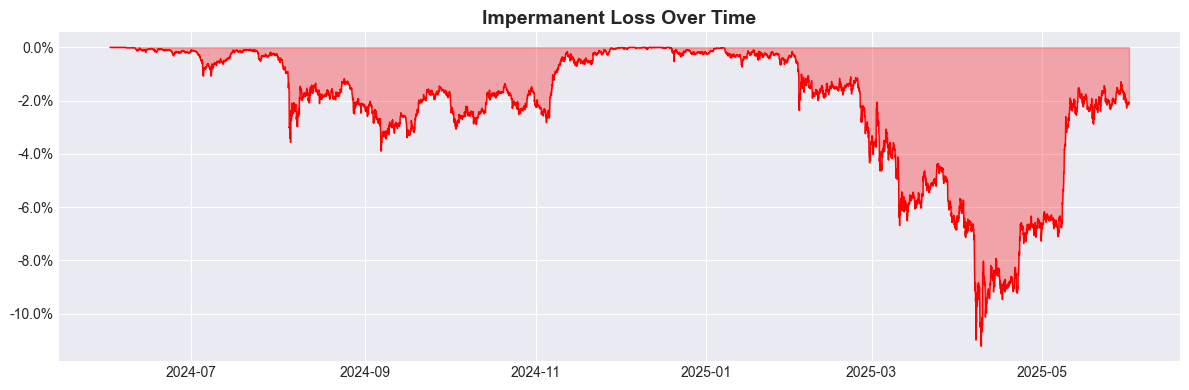

Generating Microstructure Heatmap data...


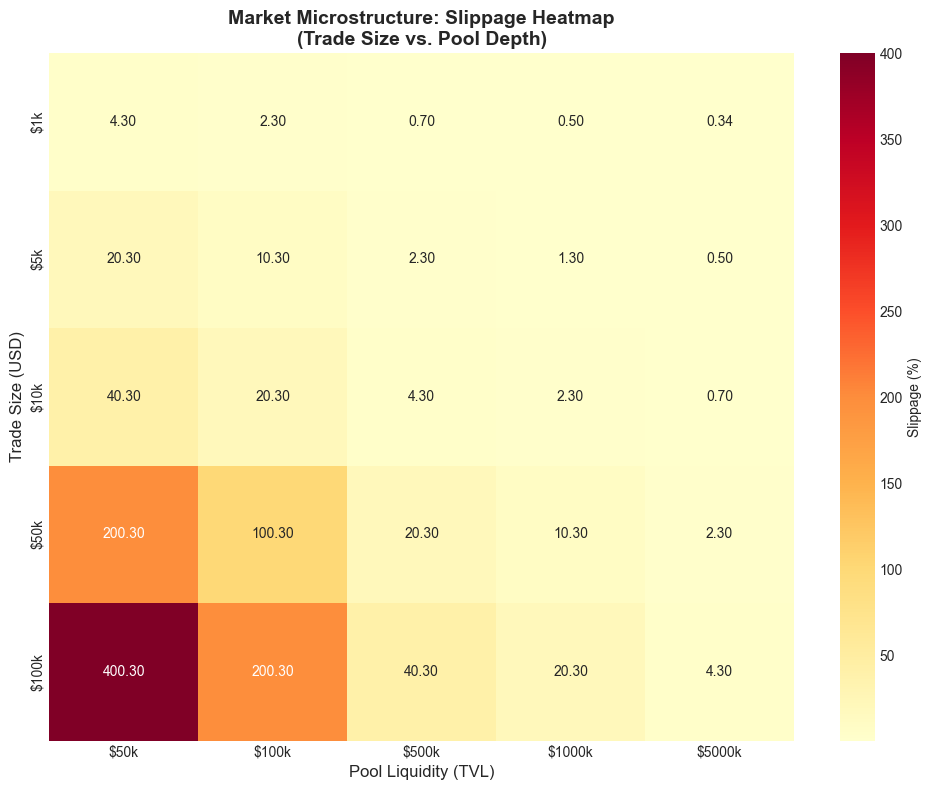


Simulation complete. Results saved to 'simulation_results.csv'.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

# --- PART 1: IMPERMANENT LOSS SIMULATION (TIME SERIES) ---
def run_liquidity_simulation(data_path, initial_investment=10000):
    """
    Simulates the performance of an LP vs HODL strategy over the historical data.
    Assumes perfect arbitrage (Pool Price always rebalances to Market Price).
    """
    print("Loading market data...")
    df = pd.read_csv(data_path, parse_dates=['Datetime'], index_col='Datetime')
    
    # Initial State
    start_price = df['Price_USD'].iloc[0]
    
    # Split investment 50/50
    initial_usdc = initial_investment / 2
    initial_eth = initial_usdc / start_price
    
    # Constant Product k
    k = initial_eth * initial_usdc
    
    print(f"--- Simulation Start ---")
    print(f"Initial Price: ${start_price:.2f}")
    print(f"LP Position: {initial_eth:.4f} ETH + {initial_usdc:.2f} USDC")
    
    # Lists to store results
    lp_values = []
    hodl_values = []
    impermanent_losses = []
    
    for current_price in df['Price_USD']:
        # 1. Calculate HODL Value (What if I just kept the initial tokens?)
        val_hodl = (initial_eth * current_price) + initial_usdc
        hodl_values.append(val_hodl)
        
        # 2. Calculate LP Value (Analytical Solution for CPMM)
        # Formula: value_lp = 2 * sqrt(k * current_price)
        # This assumes arbitrageurs instantly rebalance the pool to match market price
        val_lp = 2 * np.sqrt(k * current_price)
        lp_values.append(val_lp)
        
        # 3. Impermanent Loss %
        # Formula: (val_lp - val_hodl) / val_hodl
        il = (val_lp - val_hodl) / val_hodl
        impermanent_losses.append(il)
        
    df['Value_HODL'] = hodl_values
    df['Value_LP'] = lp_values
    df['Impermanent_Loss'] = impermanent_losses
    
    return df

# --- PART 2: SLIPPAGE MICROSTRUCTURE (HEATMAP) ---
def generate_slippage_heatmap():
    """
    Calculates slippage for various trade sizes against various pool depths.
    """
    print("Generating Microstructure Heatmap data...")
    
    # Trade Sizes (USD)
    trade_sizes = [1000, 5000, 10000, 50000, 100000]
    
    # Pool Liquidity Depths (Total Value Locked in USD)
    pool_depths = [50000, 100000, 500000, 1000000, 5000000]
    
    results = np.zeros((len(trade_sizes), len(pool_depths)))
    
    # Fixed Price for this snapshot
    price_eth = 2500 
    
    for i, trade_amt in enumerate(trade_sizes):
        for j, liquidity in enumerate(pool_depths):
            # Setup Pool
            res_usdc = liquidity / 2
            res_eth = res_usdc / price_eth
            k = res_eth * res_usdc
            
            # Simulate Buy (Swap USDC -> ETH)
            # Formula: Execution Price = Amount Out / Amount In
            amount_in_w_fee = trade_amt * 0.997
            numerator = amount_in_w_fee * res_eth
            denominator = res_usdc + amount_in_w_fee
            amount_out = numerator / denominator
            
            execution_price = trade_amt / amount_out
            market_price = res_usdc / res_eth # This is actually price_eth
            
            slippage = (execution_price - market_price) / market_price
            results[i, j] = slippage * 100 # Convert to percentage
            
    return trade_sizes, pool_depths, results

# --- PLOTTING ---
if __name__ == "__main__":
    # 1. RUN TIME SERIES SIMULATION
    sim_data = run_liquidity_simulation('data/market_data_clean.csv')
    
    # Plot 1: HODL vs LP Value
    fig1, ax1 = plt.subplots(figsize=(12, 6))
    ax1.plot(sim_data.index, sim_data['Value_HODL'], label='HODL Strategy', color='grey', alpha=0.8)
    ax1.plot(sim_data.index, sim_data['Value_LP'], label='AMM LP Strategy', color='#1f77b4', linewidth=2)
    ax1.set_title('Portfolio Value: Liquidity Provision vs. HODL', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Portfolio Value (USD)')
    ax1.legend()
    plt.tight_layout()
    plt.show()
    
    # Plot 2: Impermanent Loss
    fig2, ax2 = plt.subplots(figsize=(12, 4))
    ax2.fill_between(sim_data.index, sim_data['Impermanent_Loss'], color='red', alpha=0.3)
    ax2.plot(sim_data.index, sim_data['Impermanent_Loss'], color='red', linewidth=1)
    ax2.set_title('Impermanent Loss Over Time', fontsize=14, fontweight='bold')
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.1%}'.format(y))) # Format as %
    plt.tight_layout()
    plt.show()

    # 2. RUN MICROSTRUCTURE HEATMAP
    trades, depths, heatmap_data = generate_slippage_heatmap()
    
    # Plot 3: Heatmap
    fig3, ax3 = plt.subplots(figsize=(10, 8))
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlOrRd", 
                xticklabels=[f"${x/1000:g}k" for x in depths],
                yticklabels=[f"${x/1000:g}k" for x in trades],
                cbar_kws={'label': 'Slippage (%)'})
    
    ax3.set_title('Market Microstructure: Slippage Heatmap\n(Trade Size vs. Pool Depth)', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Pool Liquidity (TVL)', fontsize=12)
    ax3.set_ylabel('Trade Size (USD)', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Save Results
    sim_data.to_csv('data/simulation_results.csv')
    print("\nSimulation complete. Results saved to 'simulation_results.csv'.")